In [ ]:
from google.colab import files

uploaded=files.upload()
print(uploaded)

Saving archive (2).zip to archive (2).zip
{'archive (2).zip': b'PK\x03\x04-\x00\x00\x08\x08\x00bB\xc8Vl\x07\xb6E\xff\xff\xff\xff\xff\xff\xff\xff\x0c\x00\x14\x00diamonds.csv\x01\x00\x10\x00\x1a$%\x00\x00\x00\x00\x00\xb1\xb4\x08\x00\x00\x00\x00\x00\xd4\xbd\xc9\xcem9\x8e.67\xe0w\xf0\x03,\x1clIK\xdd<\xe2412\x10@\xce\xd3U\t\xb8\x80\xba\xa8\x8bD]\xc0\xe5\xa7\xf7\x16\x9b\x8f\xa4\xb4\xf6\x1f\xf6\x9dy\xf0oD\xe6!\xb5\xd4P\xecI\xfd\xcb\xdf\xff\xf9\xf7\xff\xbc\xfe\xe5\x7f\xbc\xff\xfe\xe3\xdf\xff\xe3\x9f\xd7\xbf\xfc\xfb\xdf\xff\xf9o\xff\xf9_\xd7\xbf\xfe\xe3\xbf\xff\xe7\xffy\xfd\xe7\xdf\xff\x8f\x7f\xff\xc7\xf5\xdf\xff\xf9o\xff\xf2\x8f\xeb\xff\xba\xfe\xeb\xfa\xbf\xff\xd7\xff\xe5\xf5-\x97\xeb\xd7\xbf\xfe\xe3\xef\xff~\xfd~\xfd\xf9+_-}\xabW\xad\xdf^W\xc9\xed*\xdff]?\xe3\xca\xdf\xeeB\xe0\xe9\xfa\xdf\xff\xf9\x8f\xff\xf6o\xff\xe3\xbf\x11B\xba\xea\xfc6\x16\x96"\x8c\xb9~\xee7BI2\xfe\x8f\xff\xf8\x8f\x7f}C\xff\xed\xcf7t\xfb6\xaf\xc6\xc3\xf7\xeb\xfe\xf6\xaa\xeb\xa7\x1b\xf4\xc4\xf0\xbf\xde\x08\xef\xf9\xbc?|\xd5\

In [ ]:
#kütüphaneleri iç aktarıyoruz
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#veri işleme,görselleştirme ve modelleme için gerkli kütüphaneleri yükledik
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

sns.set_theme()


In [ ]:
df=sns.load_dataset("diamonds")
print(df.head())
print(df.describe()) #veri setinin istatiksel özeti

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   
75%        1.040000  

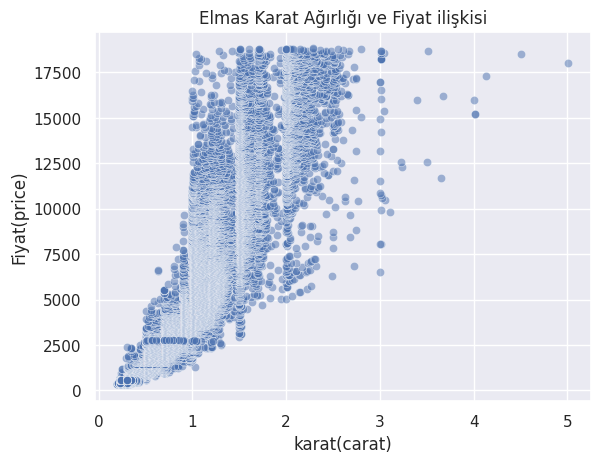

In [ ]:
#elmas fiyatlarıyla karat ağırlığı arasındaki ilişkiyi inceliyoruz
sns.scatterplot(x="carat",y="price",data=df,alpha=0.5)
plt.title("Elmas Karat Ağırlığı ve Fiyat ilişkisi")
plt.xlabel("karat(carat)")
plt.ylabel("Fiyat(price)")
plt.show()


In [ ]:
#Basit linear regresyon modeli
#carat değişkeni ile fiyat tahmini yapıyoruz
X=df[["carat"]] #bağımsız değişken(2D)
Y=df[["price"]] #bağımlı değişken(1D)

model=LinearRegression()
model.fit(X,Y)

#Y=W.X+B
print(f"Model Sabiti(b):{model.intercept_[0]:.2f}") #İNTERCEPT SABİT TERİM
print(f"katsayı(w):{model.coef_[0][0]:.2f}") #coef katsayı demek

Model Sabiti(b):-2256.36
katsayı(w):7756.43


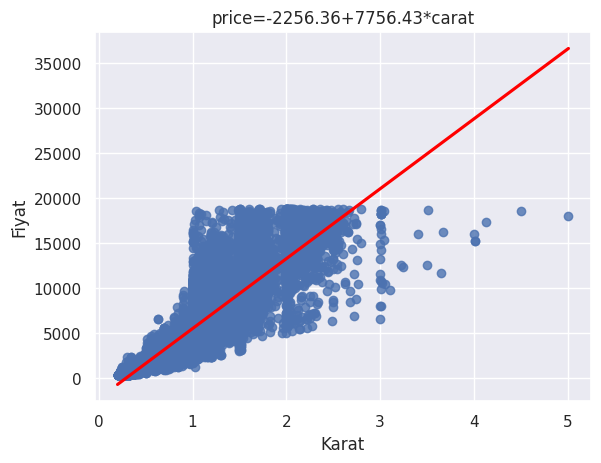

In [ ]:
#Regresyon Doğrusunun görselleştirilmesi

#scatter plot(dağılım grafiği) üzerine modelin tahmini ekliyoruz

sns.regplot(x="carat",y="price",data=df,ci=None,line_kws={"color":"red"})
plt.title(f"price={model.intercept_[0]:.2f}+{model.coef_[0][0]:.2f}*carat")
plt.xlabel("Karat")
plt.ylabel("Fiyat")
plt.show()



In [ ]:
#model perfomans değerlendirmesi
y_pred=model.predict(X)

#pred=predict
mse=mean_squared_error(Y,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y,y_pred)

print(f"Mean Squared Error(MSE):{mse:.2f}")
print(f"Root Mean Squared Error(RMSE):{rmse:.2f}")
print(f"R^2 Score:{r2:.2f}")


Mean Squared Error(MSE):2397955.05
Root Mean Squared Error(RMSE):1548.53
R^2 Score:0.85


In [ ]:
import numpy as np

yeni_elmas=np.array([1.5]).reshape(1,-1)
tahmini_fiyat=model.predict(yeni_elmas)[0]
print(f"1.5 karat elmas için tahmini fiyat: {tahmini_fiyat:}")


1.5 karat elmas için tahmini fiyat: [9378.27784691]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
